In [1]:
import os, sys
import fitz
import re
import json
from json import JSONDecodeError
from datetime import datetime
from typing import Optional, List, Callable, Any, Tuple, Dict
from abc import abstractmethod, ABC
import random
import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import pickle
from tqdm.autonotebook import tqdm
import itertools
from dotenv import load_dotenv

sys.path.append("../")

load_dotenv(dotenv_path="../.env")
nltk.download('stopwords')

random.seed(42)
np.random.seed(42)

/tmp/ipykernel_912440/365157902.py:18: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
from dataset.dataset_utils.reader import ADIQDataset
from dataset.dataset_utils.question import Question
from dataset.utils import file_handle


In [3]:
def get_all_metadata(root_fol:str, ds_loc:str):
    if not os.path.exists(root_fol):
        print("Given folder is wrong: {}".format(root_fol))

    ds = ADIQDataset(ds_loc)
    ds_ques = {k.id:k for k in ds.questions}
    res_dict = {}

    for i,file in enumerate(os.listdir(root_fol)):
        results = file_handle.load_json(
            os.path.join(root_fol,file)
        )

        model_id = file.replace(".json", "")
        res_dict[model_id] = get_evaluation_metadata(ds_ques, results["results"])

    return res_dict
    

### Step 1: Extract the JSON code block
def extract_json_block(text):
    match = re.search(r'{(.*?)}', text)
    if match:
        return match.group(1)
    return None

### Step 2: Clean the extracted string and convert to Python object
def clean_and_parse_json(json_str):
    # Unescape the string
    unescaped = json_str.encode().decode('unicode_escape')
    return unescaped

def get_evaluation_metadata(ds_ques, results):    
    evaluation_data = []
    #print(results)
    for k,v in ds_ques.items():
        data = {"id":k, "q":v, "decode-error":False, 'not-in-options':False, "no-answer":False, "true":None, "pred":None, "correct":0, "in-correct":0}
        try:
            _r = results[str(k)]['model_output']
            
            try:
                _r = json.loads(_r)
            except JSONDecodeError as e:
                _r = extract_json_block(_r)
                if not _r:
                    raise JSONDecodeError("custom", str(_r),0)
                _r = clean_and_parse_json(_r)
                _r = json.loads("{"+_r+"}")

            if 'answer' not in _r:
                raise JSONDecodeError("custom", str(_r),0)
            
            pred = _r['answer']
            data['pred'] = pred
            if len(set(pred).intersection(set(v.option_ids))) <= 0:
                data['not-in-options'] = True

                if isinstance(pred, list) and len(pred) == 0:
                    data['no-answer'] =True
            
            cor = np.array(v.option_ids)[np.array(v.correct)].tolist()
            data['true'] = cor

            if len(set(cor).intersection(pred)) > 0 and len(pred) == 1:
                data['correct'] = 1

            if len(set(cor).intersection(pred)) > 0 and len(pred) >= 1:
                data['in-correct'] = 1

        except JSONDecodeError as e:
            data['decode-error'] = True

        evaluation_data.append(data)

    return evaluation_data


        
    
def asset_wise_metrics(_data) -> dict:
    assets = set([x["q"].asset_type for x in _data])
    asset_data = {}
    for k in assets:
        correct = [x["correct"] for x in _data if x["q"].asset_type == k]
        asset_data[k] = {'count':sum(correct), 'perc':sum(correct)/len(correct)}
    return asset_data

def question_type(_data) -> dict:
    assets = set([x["q"].q for x in _data])
    asset_data = {}
    for k in assets:
        correct = [x["correct"] for x in _data if x["q"].asset_type == k]
        asset_data[k] = {'count':sum(correct), 'perc':sum(correct)/len(correct)}
    return asset_data

def evaluate(_data):
    def condition_count_percentage(d):
        counts = len([x for x in _data if x[d]])
        perc = counts/len(_data)

        return {'count':counts, 'perc':perc}
    
    metrics = {}

    metrics['overall_acc'] = condition_count_percentage('correct')
    metrics['format_errors'] = condition_count_percentage('decode-error')
    metrics['no_answers'] = condition_count_percentage('no-answer')

    metrics['asset_wise_metrics'] = asset_wise_metrics(_data)

    return metrics
    
def metadata_evaluation(_all_metadata:dict):
    eval_metrics = {}
    for model_id, meta_data in _all_metadata.items():
        eval_metrics[model_id] = evaluate(meta_data)

    return eval_metrics

    

def get_eval_data(root_fol:str, ds_loc:str):
    _metadata = get_all_metadata(root_fol,ds_loc)
    eval_met = metadata_evaluation(_metadata)

    return eval_met


In [4]:
evals_met_simple = get_eval_data("results/basic_bench/simpleV3.1", "../dataset/datasets/simpleV3.1")

In [5]:
for k,v in evals_met_simple.items():
    print("{} : {}".format(k, v['overall_acc']))

mistral-large : {'count': 4386, 'perc': 0.6556053811659193}
microsoft-phi-4 : {'count': 3209, 'perc': 0.4796711509715994}
llama-3-1-405b-instruct-fp8 : {'count': 3940, 'perc': 0.5889387144992526}
qwen2-5-72b-instruct : {'count': 4182, 'perc': 0.6251121076233184}
llama-3-3-70b-instruct : {'count': 3985, 'perc': 0.5956651718983558}
llama-3-1-8b-instruct : {'count': 2489, 'perc': 0.3720478325859492}


In [6]:
evals_met_complex = get_eval_data("results/basic_bench/complexV3.1", "../dataset/datasets/complexV3.1")

In [7]:
for k,v in evals_met_complex.items():
    print("{} : {}".format(k, v['overall_acc']))

mistral-large : {'count': 2441, 'perc': 0.3648729446935725}
microsoft-phi-4 : {'count': 1615, 'perc': 0.2414050822122571}
llama-3-1-405b-instruct-fp8 : {'count': 2360, 'perc': 0.35276532137518685}
qwen2-5-72b-instruct : {'count': 2207, 'perc': 0.3298953662182362}
llama-3-3-70b-instruct : {'count': 2127, 'perc': 0.3179372197309417}
llama-3-1-8b-instruct : {'count': 896, 'perc': 0.13393124065769807}


In [8]:
evals_met_simple_pert = get_eval_data("results/basic_bench/simplePertV3.1", "../dataset/datasets/simplePertV3.1")

In [9]:
for k,v in evals_met_simple_pert.items():
    print("{} : {}".format(k, v['overall_acc']))

mistral-large : {'count': 3840, 'perc': 0.5739910313901345}
microsoft-phi-4 : {'count': 3016, 'perc': 0.4508221225710015}
llama-3-1-405b-instruct-fp8 : {'count': 4048, 'perc': 0.6050822122571001}
qwen2-5-72b-instruct : {'count': 4204, 'perc': 0.6284005979073244}
llama-3-3-70b-instruct : {'count': 4478, 'perc': 0.6693572496263079}
llama-3-1-8b-instruct : {'count': 2954, 'perc': 0.4415545590433483}


### Model evaluations graph

In [10]:
model_renaming = {
    'llama-3-1-405b-instruct-fp8': 'llama-3-1-405b',
    'qwen2-5-72b-instruct':'qwen2-5-72b',
    'llama-3-3-70b-instruct':'llama-3-3-70b',
    'llama-3-1-8b-instruct':'llama-3-1-8b'
}

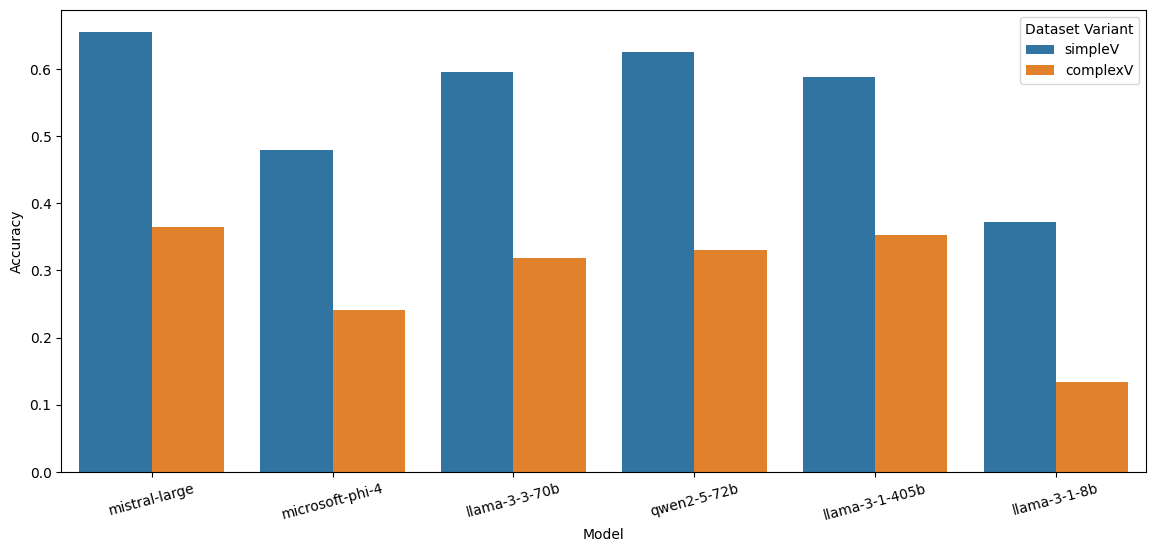

In [11]:
simple_overall_accuracy = {k:v['overall_acc']['perc'] for k,v in evals_met_simple.items()}
complex_overall_accuracy = {k:v['overall_acc']['perc'] for k,v in evals_met_complex.items()}

set_of_common_models = set(simple_overall_accuracy.keys()).intersection(complex_overall_accuracy.keys())

data = {
    "Accuracy":[],
    "Model":[],
    "Dataset":[]
}

for k in set_of_common_models:
    model_name = model_renaming.get(k, None)
    if not model_name:
        model_name = k

    data['Accuracy'].append(simple_overall_accuracy[k])
    data['Model'].append(model_name)
    data["Dataset"].append("simpleV")

    data['Accuracy'].append(complex_overall_accuracy[k])
    data['Model'].append(model_name)
    data["Dataset"].append("complexV")

df = pd.DataFrame.from_dict(data)


plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Model", y="Accuracy", hue="Dataset", )
plt.xticks(rotation=15)
plt.legend(title="Dataset Variant")

In [12]:
data_simple = get_all_metadata("results/basic_bench/simpleV3.1", "../dataset/datasets/simpleV3.1")
data_complex = get_all_metadata("results/basic_bench/complexV3.1", "../dataset/datasets/complexV3.1")
data_simple_pert = get_all_metadata("results/basic_bench/simplePertV3.1", "../dataset/datasets/simplePertV3.1")

In [13]:
from dataset.dataset_utils.question import Question
q_prompt_map = {
}

metrics = []
for n, data in {"simpleV":data_simple, "complexV": data_complex, "simplePertV": data_simple_pert}.items():
    for model,model_data in data.items():
        for dp in model_data:
            que:Question =  dp["q"]
            if dp["q"].question_prompt not in q_prompt_map:
                q_prompt_map[dp["q"].question_prompt] = len(q_prompt_map.keys())
            
            
            metrics.append({
                "model":model,
                "ds":n,
                "q_id":que.id,
                "q_type":que.question_type,
                "q_prompt":q_prompt_map[que.question_prompt],
                "asset_type":que.asset_type,
                "correct":dp["correct"],
                "in-correct":dp["in-correct"]
                })

    

In [14]:
metrics = pd.DataFrame.from_records(metrics)

In [15]:
metrics

,model,ds,q_id,q_type,q_prompt,asset_type,correct,in-correct
0,mistral-large,simpleV,827,positive,0,AHU,1,1
1,mistral-large,simpleV,3625,positive,1,AHU,0,1
2,mistral-large,simpleV,4937,positive,1,Chiller,1,1
3,mistral-large,simpleV,3493,positive,2,AHU,1,1
4,mistral-large,simpleV,681,positive,3,AHU,1,1
...,...,...,...,...,...,...,...,...
120415,llama-3-1-8b-instruct,simplePertV,701,positive,13,AHU,0,1
120416,llama-3-1-8b-instruct,simplePertV,651,positive,13,AHU,0,0
120417,llama-3-1-8b-instruct,simplePertV,0,positive,8,Air Compressor,1,1
120418,llama-3-1-8b-instruct,simplePertV,2823,positive,1,AHU,0,0


In [16]:
mistral_res = metrics.loc[metrics["model"] == "mistral-large"]

In [17]:
asset_wise = mistral_res.groupby(["asset_type", "ds"])["correct"]
asset_wise = pd.concat([asset_wise.mean(), asset_wise.sum(), asset_wise.count()], axis=1)
asset_wise.columns = ["mean", "sum", "count"]
asset_wise = asset_wise.reset_index()

In [18]:
asset_wise = asset_wise.loc[asset_wise["asset_type"] != "AHU Humidity"]
asset_wise

,asset_type,ds,mean,sum,count
0,AHU,complexV,0.368734,1427,3870
1,AHU,simplePertV,0.601809,2329,3870
2,AHU,simpleV,0.693540,2684,3870
6,Air Compressor,complexV,0.426667,64,150
7,Air Compressor,simplePertV,0.653333,98,150
8,Air Compressor,simpleV,0.653333,98,150
9,Boiler,complexV,0.574359,224,390
10,Boiler,simplePertV,0.674359,263,390
11,Boiler,simpleV,0.810256,316,390
12,CRAC,complexV,0.177778,64,360


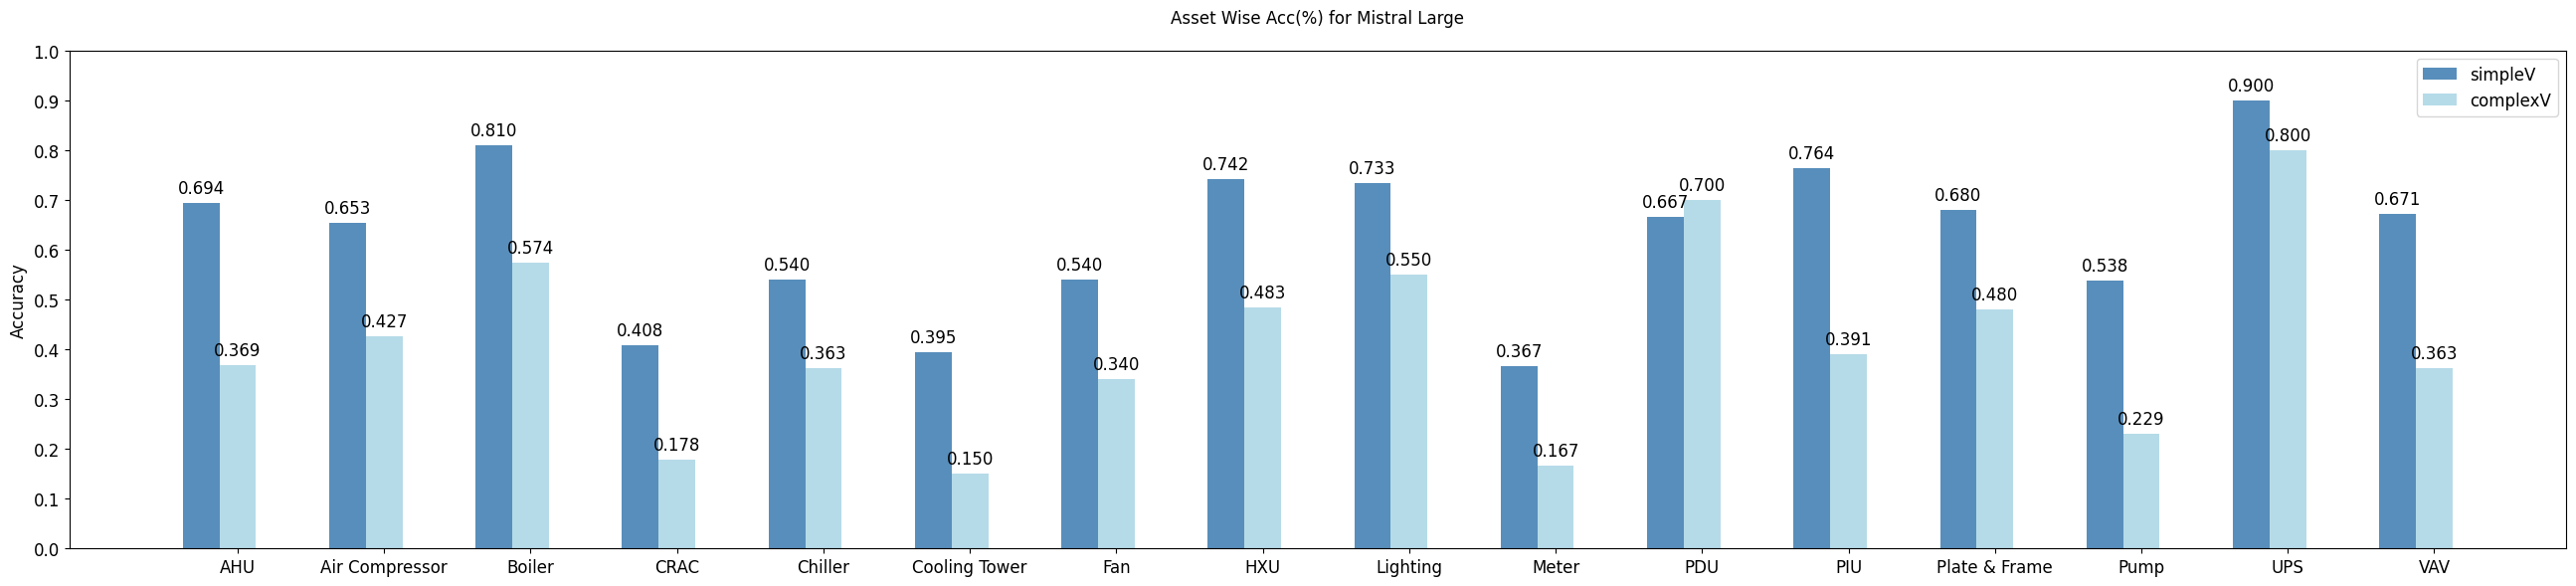

In [19]:
assets_type_names = asset_wise["asset_type"].unique()
acc_simpleV = [asset_wise.loc[(asset_wise["asset_type"] == x) & (asset_wise["ds"] == "simpleV"), "mean"].item() for x in assets_type_names]
acc_complexV =  [asset_wise.loc[(asset_wise["asset_type"] == x) & (asset_wise["ds"] == "complexV"), "mean"].item() for x in assets_type_names]


# Bar width and positions
bar_width = 0.25
x = np.arange(len(assets_type_names))

# Plotting
plt.figure(figsize=(26, 6))
plt.bar(x - bar_width, acc_simpleV, width=bar_width, label='simpleV', color='steelblue', alpha=0.9)
plt.bar(x, acc_complexV, width=bar_width, label='complexV', color='lightblue', alpha=0.9)

# Adding text annotations
for i, v in enumerate(acc_simpleV):
    plt.text(x[i] - bar_width, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)
for i, v in enumerate(acc_complexV):
    plt.text(x[i], v + 0.02, f'{v:.3f}', ha='center', fontsize=12)

# Customization
plt.xticks(x, assets_type_names, rotation=0, fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.legend(title=None, fontsize=12, loc='upper right')
plt.title('Asset Wise Acc(%) for Mistral Large', fontsize=12, pad=20)

# Display the plot
plt.tight_layout()

# result
plt.savefig('Assetwise_analysis.png', dpi=600, bbox_inches='tight')
plt.show()

In [20]:
_metrics = copy.deepcopy(metrics)
_metrics["q_type"] = _metrics["q_type"].map(
    {"positive":"selection", "negative":"elimination"}
)

q_type_results = _metrics.groupby(["model", "q_type", "ds"])["correct"]
q_type_results = pd.concat([q_type_results.mean(), q_type_results.sum(), q_type_results.count()], axis=1)
q_type_results.columns = ["mean", "sum", "count"]
q_type_results = q_type_results.reset_index()

In [21]:
q_type_results

,model,q_type,ds,mean,sum,count
0,llama-3-1-405b-instruct-fp8,elimination,complexV,0.606623,916,1510
1,llama-3-1-405b-instruct-fp8,elimination,simplePertV,0.698013,1054,1510
2,llama-3-1-405b-instruct-fp8,elimination,simpleV,0.705960,1066,1510
3,llama-3-1-405b-instruct-fp8,selection,complexV,0.278764,1444,5180
4,llama-3-1-405b-instruct-fp8,selection,simplePertV,0.577992,2994,5180
5,llama-3-1-405b-instruct-fp8,selection,simpleV,0.554826,2874,5180
6,llama-3-1-8b-instruct,elimination,complexV,0.268874,406,1510
7,llama-3-1-8b-instruct,elimination,simplePertV,0.432450,653,1510
8,llama-3-1-8b-instruct,elimination,simpleV,0.436424,659,1510
9,llama-3-1-8b-instruct,selection,complexV,0.094595,490,5180


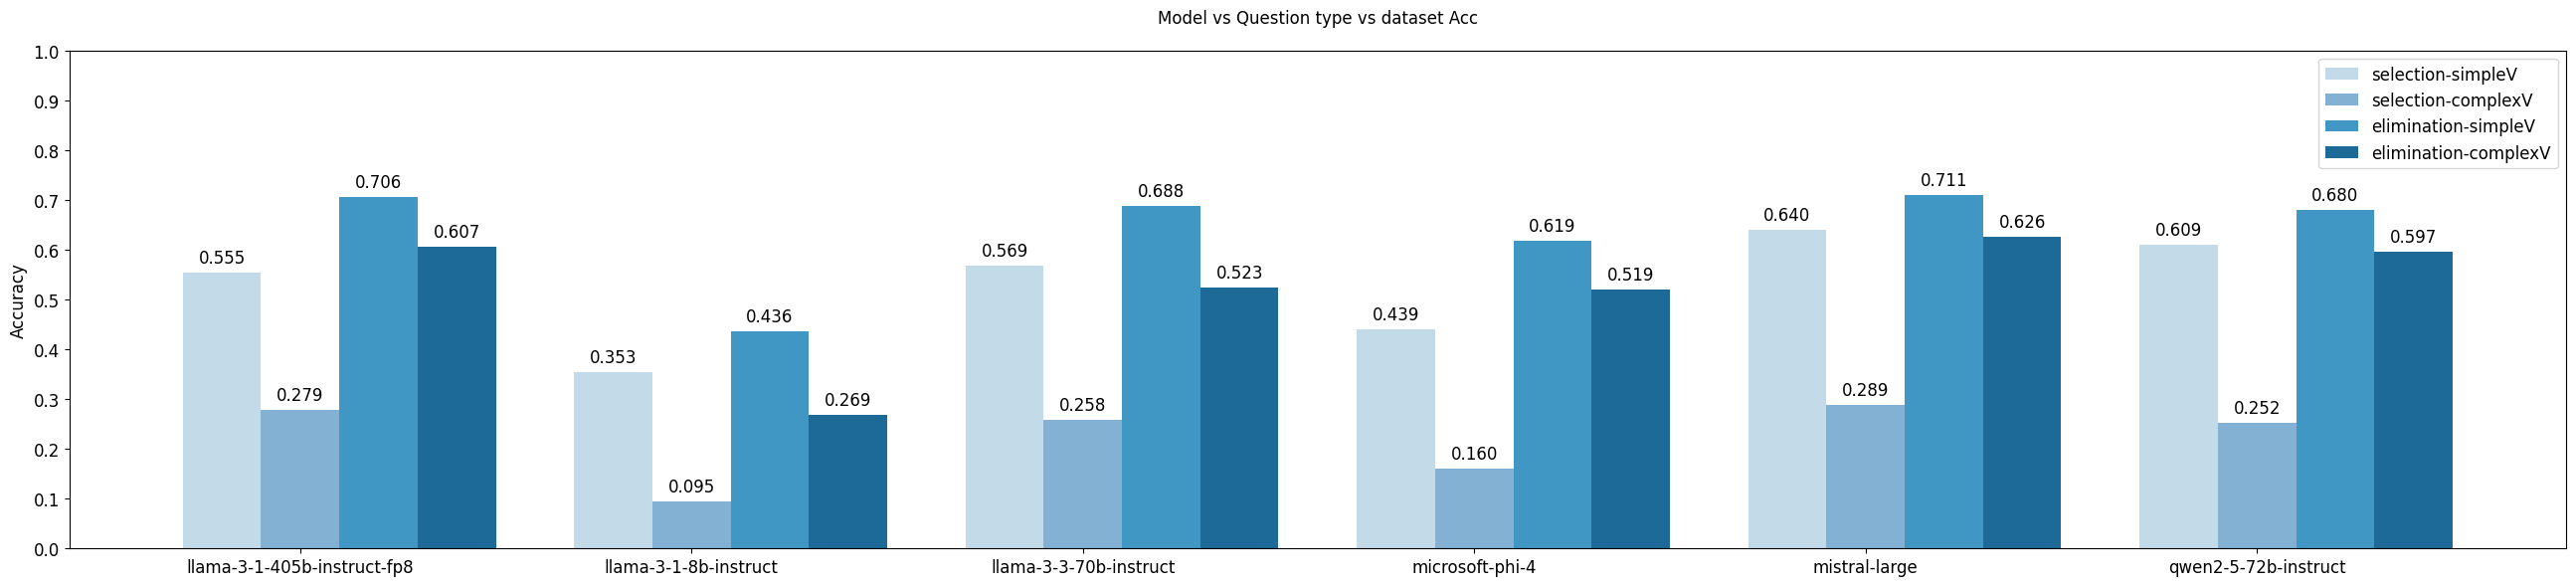

In [22]:
model_type_names = q_type_results["model"].unique()
acc_sel_simpleV = [q_type_results.loc[(q_type_results["model"] == x) & (q_type_results["ds"] == "simpleV") & (q_type_results["q_type"] == "selection"), "mean"].item() for x in model_type_names]
acc_sel_complexV =  [q_type_results.loc[(q_type_results["model"] == x) & (q_type_results["ds"] == "complexV") & (q_type_results["q_type"] == "selection"), "mean"].item() for x in model_type_names]
acc_eli_simpleV = [q_type_results.loc[(q_type_results["model"] == x) & (q_type_results["ds"] == "simpleV") & (q_type_results["q_type"] == "elimination"), "mean"].item() for x in model_type_names]
acc_eli_complexV =  [q_type_results.loc[(q_type_results["model"] == x) & (q_type_results["ds"] == "complexV") & (q_type_results["q_type"] == "elimination"), "mean"].item() for x in model_type_names]


# Bar width and positions
bar_width = 0.20
x = np.arange(len(model_type_names))

# Plotting
plt.figure(figsize=(26, 6))
plt.bar(x - bar_width, acc_sel_simpleV, width=bar_width, label='selection-simpleV', color='#bdd7e7', alpha=0.9)
plt.bar(x, acc_sel_complexV, width=bar_width, label='selection-complexV', color='#74a9cf', alpha=0.9)
plt.bar(x + bar_width, acc_eli_simpleV, width=bar_width, label='elimination-simpleV', color='#2b8cbe', alpha=0.9)
plt.bar(x +2*bar_width, acc_eli_complexV, width=bar_width, label='elimination-complexV', color='#045a8d', alpha=0.9)

# Adding text annotations
for i, v in enumerate(acc_sel_simpleV):
    plt.text(x[i] - bar_width, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)
for i, v in enumerate(acc_sel_complexV):
    plt.text(x[i], v + 0.02, f'{v:.3f}', ha='center', fontsize=12)
for i, v in enumerate(acc_eli_simpleV):
    plt.text(x[i] + bar_width, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)
for i, v in enumerate(acc_eli_complexV):
    plt.text(x[i]+ 2*bar_width, v + 0.02, f'{v:.3f}', ha='center', fontsize=12)

# Customization
plt.xticks(x, model_type_names, rotation=0, fontsize=12)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1)
plt.legend(title=None, fontsize=12, loc='upper right')
plt.title('Model vs Question type vs dataset Acc', fontsize=12, pad=20)

# Display the plot
plt.tight_layout()

# result
plt.savefig('question_type_wise_analysis.png', dpi=600, bbox_inches='tight')
plt.show()

In [23]:
_metrics = copy.deepcopy(metrics)
_metrics["q_type"] = _metrics["q_type"].map(
    {"positive":"selection", "negative":"elimination"}
)

q_prompt_results = _metrics.groupby(["model", "q_prompt", "ds"])["correct"]
q_prompt_results = pd.concat([q_prompt_results.mean(), q_prompt_results.sum(), q_prompt_results.count()], axis=1)
q_prompt_results.columns = ["mean", "sum", "count"]
q_prompt_results = q_prompt_results.reset_index()

In [24]:
q_prompt_results

,model,q_prompt,ds,mean,sum,count
0,llama-3-1-405b-instruct-fp8,0,complexV,0.255556,138,540
1,llama-3-1-405b-instruct-fp8,0,simplePertV,0.646833,337,521
2,llama-3-1-405b-instruct-fp8,0,simpleV,0.570370,308,540
3,llama-3-1-405b-instruct-fp8,1,complexV,0.384000,96,250
4,llama-3-1-405b-instruct-fp8,1,simplePertV,0.585366,288,492
...,...,...,...,...,...,...
391,qwen2-5-72b-instruct,20,simplePertV,0.740260,114,154
392,qwen2-5-72b-instruct,20,simpleV,0.922222,83,90
393,qwen2-5-72b-instruct,21,complexV,0.466667,28,60
394,qwen2-5-72b-instruct,21,simplePertV,0.704545,93,132


In [25]:
simpleV_ds = copy.deepcopy(metrics.loc[metrics['ds'] == 'simpleV'])
simplePertV_ds = copy.deepcopy(metrics.loc[metrics['ds'] == 'simplePertV'])

simpleV_ds = simpleV_ds.drop(columns=["ds", "q_type", "asset_type", "q_prompt"])
simplePertV_ds = simplePertV_ds.drop(columns=["ds", "q_type", "asset_type", "q_prompt"])

simpleV_ds = simpleV_ds.set_index(keys=["model", "q_id"])
simplePertV_ds = simplePertV_ds.set_index(keys=["model", "q_id"])

In [26]:
simpleV_ds_cp = copy.deepcopy(simpleV_ds)
simplePertV_ds_cp = copy.deepcopy(simplePertV_ds)

simpleV_ds_cp.columns = ["simple-correct", "simple-in-correct"]
simplePertV_ds_cp.columns = ["simple-pert-correct", "simple-pert-in-correct"]

In [27]:
merged = pd.concat([simpleV_ds_cp, simplePertV_ds_cp], axis=1)
merged["consist"] = merged["simple-correct"] & merged["simple-pert-correct"]

In [28]:
merged = merged.reset_index()
groupby = merged.groupby(["model"])

acc_simple = groupby["simple-correct"].mean()
acc_pert = groupby["simple-pert-correct"].mean()
acc_consist = groupby["consist"].mean()

In [29]:
acc_df = pd.DataFrame()
acc_df["acc_org"] = acc_simple
acc_df["acc_pert"] = acc_pert
acc_df["acc_consist"] = acc_consist

In [30]:
(acc_df["acc_pert"] - acc_df["acc_org"])/acc_df["acc_org"]

model
llama-3-1-405b-instruct-fp8    0.027411
llama-3-1-8b-instruct          0.186822
llama-3-3-70b-instruct         0.123714
microsoft-phi-4               -0.060143
mistral-large                 -0.124487
qwen2-5-72b-instruct           0.005261
dtype: float64

In [31]:
simpleV_ds = simpleV_ds.reset_index()
simplePertV_ds = simplePertV_ds.reset_index()

In [32]:
from scipy.stats import wilcoxon

models = set(simplePertV_ds['model']).intersection(simpleV_ds['model'])
for m in models:
    a = simplePertV_ds.loc[simplePertV_ds['model'] == m]
    a = a.set_index(['q_id'])
    a = np.array(a.sort_index()['correct'])

    b = simpleV_ds.loc[simpleV_ds['model'] == m]
    b = b.set_index(['q_id'])
    b = np.array(b.sort_index()['correct'])
    res = wilcoxon(b,a)
    
    print("{} : {}".format(m,res))

mistral-large : WilcoxonResult(statistic=np.float64(382938.5), pvalue=np.float64(5.254541859310214e-44))
microsoft-phi-4 : WilcoxonResult(statistic=np.float64(895404.0), pvalue=np.float64(1.5228695503325587e-05))
llama-3-3-70b-instruct : WilcoxonResult(statistic=np.float64(388608.0), pvalue=np.float64(1.0145275994533947e-36))
qwen2-5-72b-instruct : WilcoxonResult(statistic=np.float64(500877.0), pvalue=np.float64(0.5601694361688956))
llama-3-1-405b-instruct-fp8 : WilcoxonResult(statistic=np.float64(628503.0), pvalue=np.float64(0.007656130052199658))
llama-3-1-8b-instruct : WilcoxonResult(statistic=np.float64(1147434.0), pvalue=np.float64(1.7725098916766772e-21))


In [ ]:
from sklearn.metrics import recall_score, precision_score, accuracy_score
import numpy as np

def consist_score(x:np.array, y:np.array):
    assert(len(x) == len(y))
    n_both_correct = 0
    for a, b in zip(x,y):
        n_both_correct += (a == 1 and b == 1)
    result = n_both_correct / len(x)
    return result

def joint_analysis(left_df,right_df):

    merge_df['score_x'] = (merge_df['true_answer_x'] == merge_df['model_output_x']).astype(int)
    merge_df['score_y'] = (merge_df['true_answer_y'] == merge_df['model_output_y']).astype(int)

    score_x = merge_df['score_x'].mean()
    score_y = merge_df['score_y'].mean()
    # wilcoxon_result = wilcoxon(
    #     merge_df['score_x'].values,
    #     merge_df['score_y'].values,
    #     alternative = 'greater'
    # )

    print('MCQ Benchmark Performance:')
    print(f"score_1 = {score_x.round(4)} ({merge_df['score_x'].sum()}/{merge_df.shape[0]})")
    print(f"score_2 = {score_y.round(4)} ({merge_df['score_y'].sum()}/{merge_df.shape[0]})")
    print(f"performance_drop_rate = {((score_y-score_x)).round(4)}")
    # print(f"Wilcoxon hypothesis test = {wilcoxon_result}")
    
    recall_c = recall_score(merge_df['score_x'], merge_df['score_y'])
    consist_c = consist_score(merge_df['score_x'], merge_df['score_y'])

    # print('Performance Consistency:')
    print(f"recall_c = {round(recall_c,4)}")
    print(f"acc@consist = {round(consist_c,4)}")
    
    return merge_df

def transition_analysis(merged_df):
    score_xs = []
    score_ys = []
    rops = []
    css = []
    for subject in [merged_df]:
        result = joint_analysis(subject)
        score_xs.append(result['score_x'].mean())
        score_ys.append(result['score_y'].mean())
        rops.append(recall_score(result['score_x'], result['score_y']))
        css.append(consist_score(result['score_x'], result['score_y']))


    score_xs = np.array(score_xs)
    score_ys = np.array(score_ys)
    macro_pdr = np.mean(score_ys - score_xs)
    macro_rop = np.mean(rops)
    macro_css = np.mean(css)
    print(f"macro_acc (before) = {np.mean(score_xs)}")
    print(f"macro_acc (after) = {np.mean(score_ys)}")
    print(f"macro_pdr = {macro_pdr}")
    print(f"macro_rop = {macro_rop}")
    print(f"macro_acc@consist = {macro_css}")
    return score_xs[0], score_ys[0], css[0]

In [69]:
metrics

,model,ds,q_id,q_type,q_prompt,asset_type,correct,in-correct
0,mistral-large,simpleV,827,positive,0,AHU,1,1
1,mistral-large,simpleV,3625,positive,1,AHU,0,1
2,mistral-large,simpleV,4937,positive,1,Chiller,1,1
3,mistral-large,simpleV,3493,positive,2,AHU,1,1
4,mistral-large,simpleV,681,positive,3,AHU,1,1
...,...,...,...,...,...,...,...,...
120415,llama-3-1-8b-instruct,simplePertV,701,positive,13,AHU,0,1
120416,llama-3-1-8b-instruct,simplePertV,651,positive,13,AHU,0,0
120417,llama-3-1-8b-instruct,simplePertV,0,positive,8,Air Compressor,1,1
120418,llama-3-1-8b-instruct,simplePertV,2823,positive,1,AHU,0,0
